---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Paths
DATA_DIR = Path('../data/features')
print(f"Looking for data in: {DATA_DIR.resolve()}")

Looking for data in: /workspaces/player-v-tactical-analysis/data/features


In [2]:
# Load feature CSVs
player_features_file = list(DATA_DIR.glob('player_match_features_*.csv'))[0]
team_features_file = list(DATA_DIR.glob('team_match_features_*.csv'))[0]

player_match_df = pd.read_csv(player_features_file)
team_match_df = pd.read_csv(team_features_file)

print(f"Player match features: {player_match_df.shape}")
print(f"Team match features: {team_match_df.shape}")
print(f"\nSeasons: {team_match_df['season_name'].unique()}")
print(f"Teams: {team_match_df['team_source_id'].nunique()}")

Player match features: (4359, 29)
Team match features: (278, 32)

Seasons: ['2022' '2018' '2009/2010' '2010/2011' '2011/2012' '2012/2013' '2013/2014'
 '2014/2015' '2015/2016' '2016/2017' '2017/2018' '2018/2019' '2008/2009']
Teams: 51


### Season Normalization

Football seasons run from August to July. Normalize all season names to `YYYY/YYYY` format.

In [3]:
import sys
sys.path.append('..')
from src.utils import normalize_season_name, sort_seasons

def normalize_season_column(df):
    """Ensure all seasons are in YYYY/YYYY format"""
    def fix_season(s):
        if '/' in str(s):
            return s
        try:
            year = int(s)
            return f"{year}/{year+1}"
        except:
            return s
    
    df['season_name'] = df['season_name'].apply(fix_season)
    return df

# Normalize seasons in both dataframes
print("Original season values:")
print(f"Team: {sorted(team_match_df['season_name'].unique())}")
print(f"Player: {sorted(player_match_df['season_name'].unique())}")

team_match_df = normalize_season_column(team_match_df)
player_match_df = normalize_season_column(player_match_df)

print("\nNormalized season values:")
print(f"Team: {sort_seasons(team_match_df['season_name'].unique())}")
print(f"Player: {sort_seasons(player_match_df['season_name'].unique())}")

Original season values:
Team: ['2008/2009', '2009/2010', '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018', '2018/2019', '2022']
Player: ['2008/2009', '2009/2010', '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018', '2018/2019', '2022']

Normalized season values:
Team: ['2008/2009', '2009/2010', '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018/2019', '2022/2023']
Player: ['2008/2009', '2009/2010', '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018/2019', '2022/2023']


In [4]:
# Preview team match features
team_match_df.head()

,source,competition_id,competition_source_id,season_id,season_name,match_id,team_id,team_source_id,is_home,possessions,...,transition_speed_sec,width_utilization_pct,cross_rate,central_overload_rate,through_ball_rate,set_piece_xg_share,passing_network_centralization,passing_clustering_coeff,passing_asymmetry,match_outcome
0,statsbomb,1,43,1,2022/2023,1,1,776,True,54,...,86.185185,36.222910,0.222222,3.314815,0.000000,0.0,0.508711,0.398169,-0.051084,D
1,statsbomb,1,43,1,2022/2023,1,2,777,False,63,...,70.000000,36.211031,0.047619,1.793651,0.031746,0.0,0.542138,0.381174,-0.021583,D
2,statsbomb,1,43,1,2022/2023,2,4,772,False,65,...,33.015385,27.538884,0.200000,5.061538,0.092308,0.0,0.722956,0.443603,0.033852,L
3,statsbomb,1,43,1,2022/2023,2,3,778,True,37,...,169.513514,27.667984,0.135135,2.378378,0.000000,0.0,0.598148,0.439759,-0.023715,W
4,statsbomb,1,43,1,2022/2023,3,6,773,False,58,...,57.245283,36.179775,0.189655,1.913793,0.068966,0.0,0.542067,0.391140,-0.114607,W


In [5]:
# Preview player match features
player_match_df.head()

,source,competition_id,competition_source_id,season_id,season_name,match_id,team_id,team_source_id,player_source_id,minutes_played,...,tackles_won_per90,interceptions_per90,ball_recoveries_per90,xg,xa,xg_xa_per90,shot_creation_actions,final_third_entries,aerial_duel_win_pct,pressure_regains
0,statsbomb,1,43,1,2022/2023,1,1,776,NaN,97.833333,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0,0,0.0,0
1,statsbomb,1,43,1,2022/2023,1,1,776,16190.0,95.983333,...,0.937663,0.937663,0.937663,0.000000,0.0,0.000000,31,9,0.0,2
2,statsbomb,1,43,1,2022/2023,1,1,776,16554.0,95.983333,...,0.937663,0.000000,2.812988,0.028684,0.0,0.026896,24,6,0.0,1
3,statsbomb,1,43,1,2022/2023,1,1,776,17042.0,64.983333,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,22,4,0.0,2
4,statsbomb,1,43,1,2022/2023,1,1,776,18722.0,30.950000,...,0.000000,0.000000,0.000000,0.028724,0.0,0.083526,12,8,0.0,0


---
## 2. Build Aggregated Feature Tables

Create season-level aggregations:
- `f_team_season_style` — Team tactical metrics aggregated by season
- `f_squad_season_skill` — Player skills aggregated to team-season level
- `f_player_season_profile` — Individual player season profiles

In [6]:
# Define indicator categories

# Evolution Indicators (what we want to explain)
EVOLUTION_INDICATORS = [
    'ppda',                      # Pressing intensity
    'ppda_final_third',          # High-zone pressing
    'high_press_pct',            # Gegenpressing adoption
    'vertical_compactness',      # Team shape
    'transition_speed_sec',      # Counter-attack speed
    'build_up_pass_share',       # Positional play
    'gk_short_build_rate',       # Build from back
]

# Tactical Setup Indicators (system-driven)
TACTICAL_INDICATORS = [
    'line_height_def',           # Defensive line position
    'line_height_att',           # Attacking line position
    'cb_split_width',            # Formation width
    'pivot_involvement_pct',     # Midfield structure
    'width_utilization_pct',     # Wing usage
    'cross_rate',                # Crossing tendency
    'central_overload_rate',     # Central play
    'through_ball_rate',         # Direct passing style
    'passing_network_centralization',  # Star dependency
    'passing_clustering_coeff',  # Pass network density
    'passing_asymmetry',         # Left/right bias
]

# Player Skill Indicators (player-driven)
PLAYER_SKILL_INDICATORS = [
    'progressive_carries',       # Ball carrying
    'progressive_passes',        # Vision/technique
    'progressive_actions_per90', # Combined progression
    'pass_completion_pct',       # Technical accuracy
    'dribble_success_pct',       # 1v1 skill
    'touch_quality',             # Ball control
    'pressure_actions_per90',    # Work rate
    'tackles_won_per90',         # Defensive skill
    'interceptions_per90',       # Reading of game
    'ball_recoveries_per90',     # Recovery ability
    'xg',                        # Goal threat
    'xa',                        # Creativity
    'xg_xa_per90',               # Combined output
    'aerial_duel_win_pct',       # Physical dominance
    'pressure_regains',          # Pressing effectiveness
]

print(f"Evolution indicators: {len(EVOLUTION_INDICATORS)}")
print(f"Tactical indicators: {len(TACTICAL_INDICATORS)}")
print(f"Player skill indicators: {len(PLAYER_SKILL_INDICATORS)}")

Evolution indicators: 7
Tactical indicators: 11
Player skill indicators: 15


In [7]:
# Build f_team_season_style: aggregate team match features by season
team_numeric_cols = team_match_df.select_dtypes(include=[np.number]).columns.tolist()
team_numeric_cols = [c for c in team_numeric_cols if c not in ['competition_id', 'season_id', 'match_id', 'team_id']]

f_team_season_style = team_match_df.groupby(['team_source_id', 'season_name']).agg(
    {col: ['mean', 'std'] for col in team_numeric_cols}
).reset_index()

# Flatten column names
f_team_season_style.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col 
                                for col in f_team_season_style.columns]

print(f"Team season style: {f_team_season_style.shape}")
f_team_season_style.head()

Team season style: (86, 50)


,team_source_id,season_name,competition_source_id_mean,competition_source_id_std,team_source_id_mean,team_source_id_std,possessions_mean,possessions_std,ppda_mean,ppda_std,...,through_ball_rate_mean,through_ball_rate_std,set_piece_xg_share_mean,set_piece_xg_share_std,passing_network_centralization_mean,passing_network_centralization_std,passing_clustering_coeff_mean,passing_clustering_coeff_std,passing_asymmetry_mean,passing_asymmetry_std
0,24,2017/2018,16.0,NaN,24.0,NaN,56.0,NaN,4.050633,NaN,...,0.053571,NaN,0.0,NaN,0.401515,NaN,0.372711,NaN,-0.030556,NaN
1,24,2018/2019,16.0,NaN,24.0,NaN,52.0,NaN,1.424460,NaN,...,0.192308,NaN,0.0,NaN,0.612536,NaN,0.388567,NaN,-0.006135,NaN
2,33,2011/2012,16.0,NaN,33.0,NaN,56.0,NaN,5.929577,NaN,...,0.000000,NaN,0.0,NaN,0.462222,NaN,0.468889,NaN,0.001789,NaN
3,38,2018/2019,16.0,NaN,38.0,NaN,63.0,NaN,3.941176,NaN,...,0.158730,NaN,0.0,NaN,0.520710,NaN,0.421913,NaN,0.030142,NaN
4,39,2008/2009,16.0,NaN,39.0,NaN,45.0,NaN,7.916667,NaN,...,0.066667,NaN,0.0,NaN,0.502959,NaN,0.378053,NaN,-0.053608,NaN


In [8]:
# Build f_squad_season_skill: aggregate player skills to team-season level
# Filter out rows with no player (team-level aggregates)
player_with_id = player_match_df[player_match_df['player_source_id'].notna()].copy()

player_numeric_cols = [c for c in PLAYER_SKILL_INDICATORS if c in player_with_id.columns]

# Aggregate to team-season (squad-level skill profile)
f_squad_season_skill = player_with_id.groupby(['team_source_id', 'season_name']).agg(
    {col: ['mean', 'std', 'max'] for col in player_numeric_cols}
).reset_index()

# Flatten column names
f_squad_season_skill.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col 
                                 for col in f_squad_season_skill.columns]

print(f"Squad season skill: {f_squad_season_skill.shape}")
f_squad_season_skill.head()

Squad season skill: (86, 47)


,team_source_id,season_name,progressive_carries_mean,progressive_carries_std,progressive_carries_max,progressive_passes_mean,progressive_passes_std,progressive_passes_max,progressive_actions_per90_mean,progressive_actions_per90_std,...,xa_max,xg_xa_per90_mean,xg_xa_per90_std,xg_xa_per90_max,aerial_duel_win_pct_mean,aerial_duel_win_pct_std,aerial_duel_win_pct_max,pressure_regains_mean,pressure_regains_std,pressure_regains_max
0,24,2017/2018,1.692308,2.750291,8,9.615385,6.994503,20,11.870613,7.389933,...,0.0,0.124392,0.188451,0.666969,0.0,0.0,0.0,1.230769,1.300887,4
1,24,2018/2019,1.785714,2.044827,7,11.000000,10.770330,31,16.186564,12.190118,...,0.0,0.096731,0.237528,0.897797,0.0,0.0,0.0,1.500000,1.454436,4
2,33,2011/2012,3.384615,2.501282,9,16.384615,13.793347,54,15.986088,9.402923,...,0.0,0.243191,0.319334,0.715010,0.0,0.0,0.0,1.230769,1.235168,4
3,38,2018/2019,2.642857,2.437121,8,12.428571,10.241051,32,16.792353,8.798586,...,0.0,0.099734,0.183670,0.635037,0.0,0.0,0.0,0.785714,1.188313,4
4,39,2008/2009,2.285714,2.233609,8,12.071429,10.873145,34,17.546788,9.823180,...,0.0,0.134835,0.240215,0.737554,0.0,0.0,0.0,0.571429,0.937614,3


In [9]:
# Build f_player_season_profile: individual player profiles per season
f_player_season_profile = player_with_id.groupby(['player_source_id', 'team_source_id', 'season_name']).agg(
    {col: 'mean' for col in player_numeric_cols}
).reset_index()

# Add total minutes
minutes_agg = player_with_id.groupby(['player_source_id', 'season_name'])['minutes_played'].sum().reset_index()
minutes_agg.columns = ['player_source_id', 'season_name', 'total_minutes']
f_player_season_profile = f_player_season_profile.merge(minutes_agg, on=['player_source_id', 'season_name'])

print(f"Player season profiles: {f_player_season_profile.shape}")
f_player_season_profile.head()

Player season profiles: (1581, 19)


,player_source_id,team_source_id,season_name,progressive_carries,progressive_passes,progressive_actions_per90,pass_completion_pct,dribble_success_pct,touch_quality,pressure_actions_per90,tackles_won_per90,interceptions_per90,ball_recoveries_per90,xg,xa,xg_xa_per90,aerial_duel_win_pct,pressure_regains,total_minutes
0,2941.0,787,2018/2019,7.666667,4.666667,12.043861,72.513441,25.000000,0.041749,23.236611,0.326205,0.319206,2.602894,0.083083,0.0,0.081203,0.0,3.000000,275.916667
1,2941.0,787,2022/2023,4.750000,4.000000,8.402906,71.787302,81.250000,0.044312,12.708705,0.225038,0.763835,4.261629,0.462198,0.0,0.442911,0.0,1.500000,363.850000
2,2948.0,771,2018/2019,1.166667,2.333333,17.646806,65.079365,38.888889,0.081654,54.141233,0.602410,0.000000,7.876696,0.009970,0.0,0.044908,0.0,0.833333,88.216667
3,2954.0,782,2018/2019,2.750000,7.250000,19.518916,85.433650,50.000000,0.000000,52.467270,1.107548,0.577046,1.833485,0.029818,0.0,0.032415,0.0,1.250000,184.300000
4,2954.0,782,2022/2023,1.000000,5.333333,15.928967,83.450292,33.333333,0.000000,15.595046,0.000000,3.836608,2.126468,0.000000,0.0,0.000000,0.0,0.666667,103.933333


---
## 3. Evolution Indicators Screening

For each evolution indicator, analyze:
- Time-series behavior (per season)
- Variance across teams
- Trend strength
- Noise ratio (std/mean)
- Interpretability

In [10]:
def screen_evolution_indicator(df, indicator, group_col='season_name'):
    """Compute screening metrics for an evolution indicator."""
    if indicator not in df.columns:
        return None
    
    data = df[indicator].dropna()
    
    # Basic stats
    mean_val = data.mean()
    std_val = data.std()
    noise_ratio = std_val / mean_val if mean_val != 0 else np.inf
    
    # Missingness
    missing_pct = df[indicator].isna().mean() * 100
    
    # Inter-season variation (if multiple seasons)
    season_means = df.groupby(group_col)[indicator].mean()
    inter_season_var = season_means.std() / season_means.mean() if len(season_means) > 1 else 0
    
    # Trend strength (simple linear regression on season means)
    if len(season_means) > 1:
        x = np.arange(len(season_means))
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, season_means.values)
        trend_r2 = r_value ** 2
    else:
        slope, trend_r2 = 0, 0
    
    return {
        'indicator': indicator,
        'mean': round(mean_val, 3),
        'std': round(std_val, 3),
        'noise_ratio': round(noise_ratio, 3),
        'missing_pct': round(missing_pct, 1),
        'inter_season_cv': round(inter_season_var, 3),
        'trend_slope': round(slope, 4),
        'trend_r2': round(trend_r2, 3),
    }

# Screen all evolution indicators
evolution_screening = []
for ind in EVOLUTION_INDICATORS:
    result = screen_evolution_indicator(team_match_df, ind)
    if result:
        evolution_screening.append(result)

evolution_screening_df = pd.DataFrame(evolution_screening)
evolution_screening_df

,indicator,mean,std,noise_ratio,missing_pct,inter_season_cv,trend_slope,trend_r2
0,ppda,3.744,2.624,0.701,0.0,0.212,-0.0191,0.006
1,ppda_final_third,4.039,3.130,0.775,0.0,0.267,-0.1279,0.134
2,high_press_pct,21.311,8.538,0.401,0.0,0.245,0.4181,0.112
3,vertical_compactness,21.830,6.430,0.295,0.0,0.167,-0.3505,0.093
4,transition_speed_sec,65.036,26.495,0.407,0.0,0.204,1.7521,0.327
5,build_up_pass_share,4.673,3.041,0.651,0.0,0.265,-0.2871,0.552
6,gk_short_build_rate,32.761,20.076,0.613,0.0,0.490,0.9254,0.081


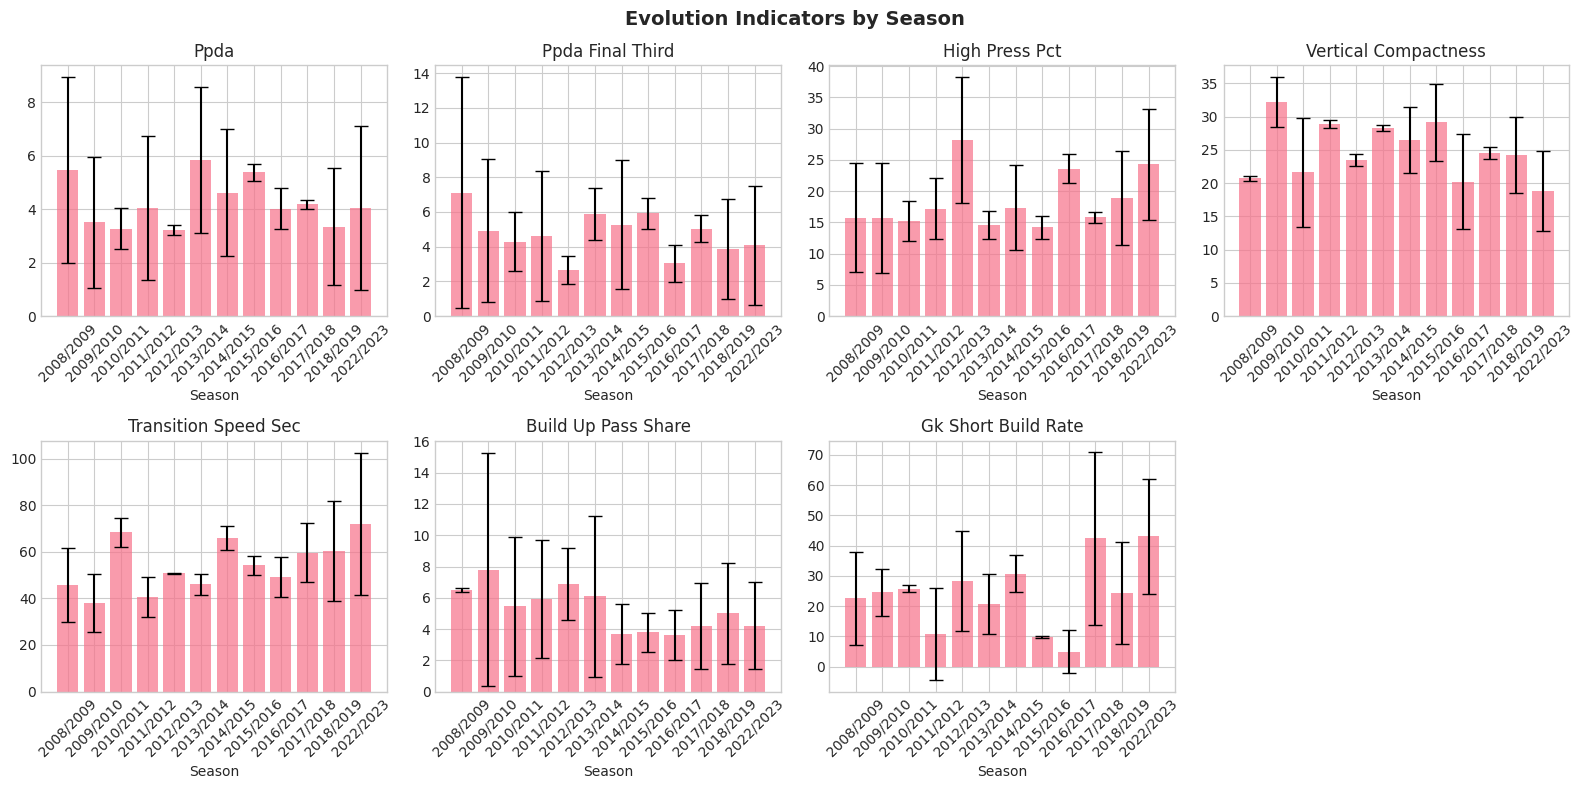

In [11]:
# Visualize evolution indicators by season
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, indicator in enumerate(EVOLUTION_INDICATORS):
    if i >= len(axes):
        break
    ax = axes[i]
    
    season_data = team_match_df.groupby('season_name')[indicator].agg(['mean', 'std']).reset_index()
    
    ax.bar(season_data['season_name'].astype(str), season_data['mean'], 
           yerr=season_data['std'], capsize=5, alpha=0.7)
    ax.set_title(indicator.replace('_', ' ').title())
    ax.set_xlabel('Season')
    ax.tick_params(axis='x', rotation=45)

# Hide unused subplot
if len(EVOLUTION_INDICATORS) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Evolution Indicators by Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

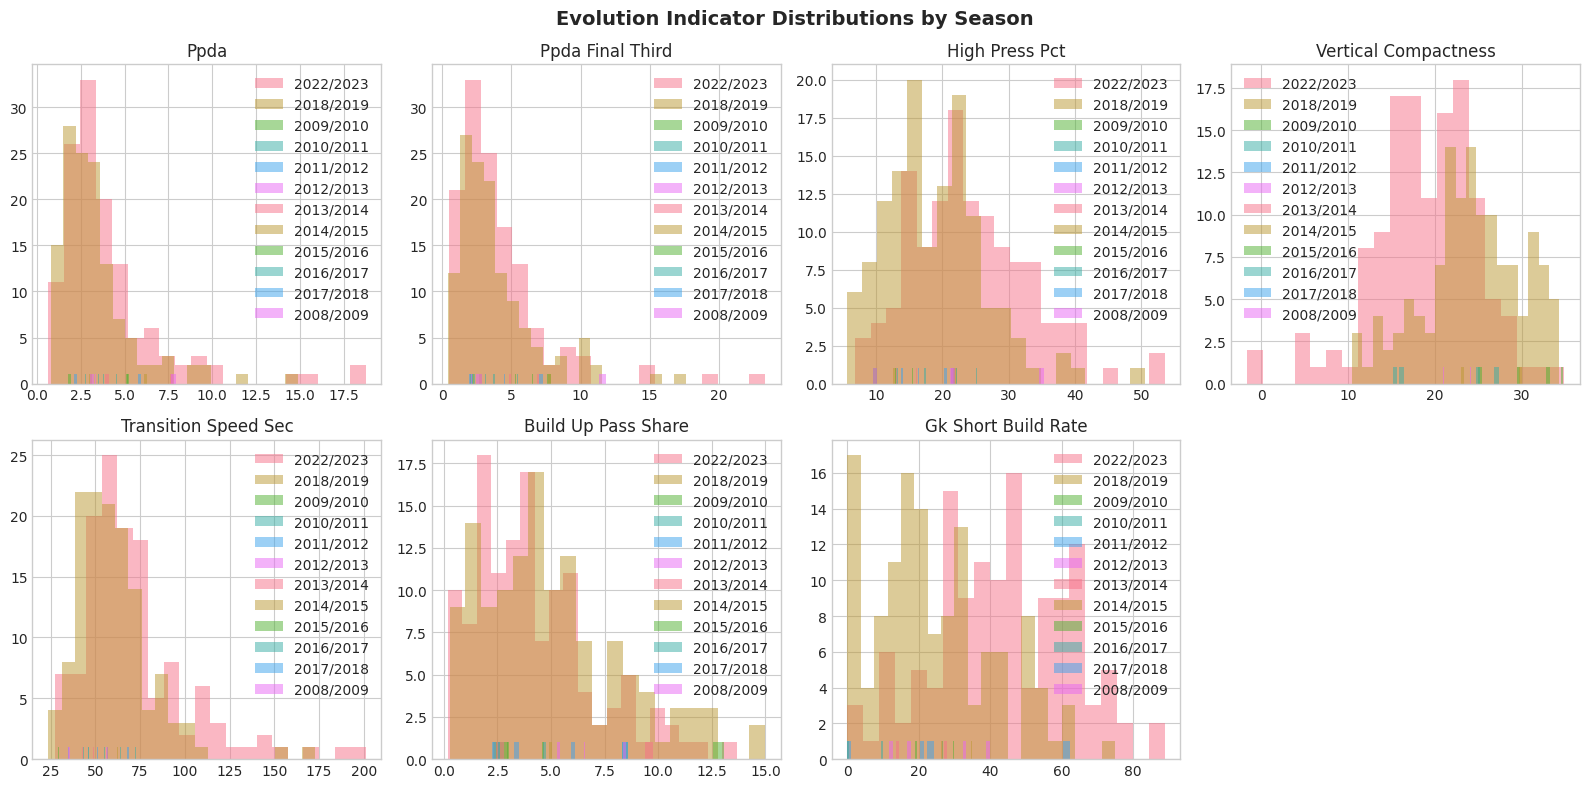

In [12]:
# Evolution indicator distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, indicator in enumerate(EVOLUTION_INDICATORS):
    if i >= len(axes):
        break
    ax = axes[i]
    
    for season in team_match_df['season_name'].unique():
        data = team_match_df[team_match_df['season_name'] == season][indicator].dropna()
        ax.hist(data, alpha=0.5, label=str(season), bins=20)
    
    ax.set_title(indicator.replace('_', ' ').title())
    ax.legend()

if len(EVOLUTION_INDICATORS) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Evolution Indicator Distributions by Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Player Skill Indicators Screening

For each skill indicator, analyze:
- Distribution
- Correlation with evolution metrics
- Whether player-driven or system-influenced
- Redundancy with other skill metrics

In [13]:
def screen_skill_indicator(player_df, team_df, indicator, evolution_indicators):
    """Screen a player skill indicator."""
    if indicator not in player_df.columns:
        return None
    
    data = player_df[indicator].dropna()
    
    # Basic stats
    mean_val = data.mean()
    std_val = data.std()
    noise_ratio = std_val / mean_val if mean_val != 0 else np.inf
    missing_pct = player_df[indicator].isna().mean() * 100
    
    # Aggregate to team-match level and correlate with evolution
    team_agg = player_df.groupby(['team_source_id', 'match_id'])[indicator].mean().reset_index()
    team_agg.columns = ['team_source_id', 'match_id', f'{indicator}_squad_avg']
    
    merged = team_df.merge(team_agg, on=['team_source_id', 'match_id'], how='left')
    
    # Correlation with evolution indicators
    correlations = {}
    for evo in evolution_indicators:
        if evo in merged.columns and f'{indicator}_squad_avg' in merged.columns:
            corr = merged[[evo, f'{indicator}_squad_avg']].dropna().corr().iloc[0, 1]
            correlations[evo] = round(corr, 3) if not np.isnan(corr) else 0
    
    max_corr_evo = max(correlations.items(), key=lambda x: abs(x[1]))[0] if correlations else None
    max_corr_val = correlations.get(max_corr_evo, 0)
    
    return {
        'indicator': indicator,
        'mean': round(mean_val, 3),
        'std': round(std_val, 3),
        'noise_ratio': round(noise_ratio, 3),
        'missing_pct': round(missing_pct, 1),
        'max_evo_corr': max_corr_val,
        'max_evo_corr_with': max_corr_evo,
    }

# Screen all skill indicators
skill_screening = []
for ind in PLAYER_SKILL_INDICATORS:
    result = screen_skill_indicator(player_match_df, team_match_df, ind, EVOLUTION_INDICATORS)
    if result:
        skill_screening.append(result)

skill_screening_df = pd.DataFrame(skill_screening)
skill_screening_df.sort_values('max_evo_corr', key=abs, ascending=False)

,indicator,mean,std,noise_ratio,missing_pct,max_evo_corr,max_evo_corr_with
3,pass_completion_pct,72.790,24.843,0.341,0.0,-0.720,build_up_pass_share
2,progressive_actions_per90,14.970,10.962,0.732,0.0,-0.617,transition_speed_sec
0,progressive_carries,2.511,2.955,1.177,0.0,-0.596,build_up_pass_share
1,progressive_passes,10.091,9.332,0.925,0.0,-0.594,transition_speed_sec
6,pressure_actions_per90,13.643,12.451,0.913,0.0,-0.398,high_press_pct
5,touch_quality,0.017,0.029,1.666,0.0,0.309,transition_speed_sec
10,xg,0.101,0.236,2.332,0.0,-0.285,transition_speed_sec
4,dribble_success_pct,24.778,39.029,1.575,0.0,-0.267,transition_speed_sec
9,ball_recoveries_per90,3.700,4.148,1.121,0.0,-0.235,transition_speed_sec
8,interceptions_per90,0.794,1.442,1.816,0.0,0.225,build_up_pass_share


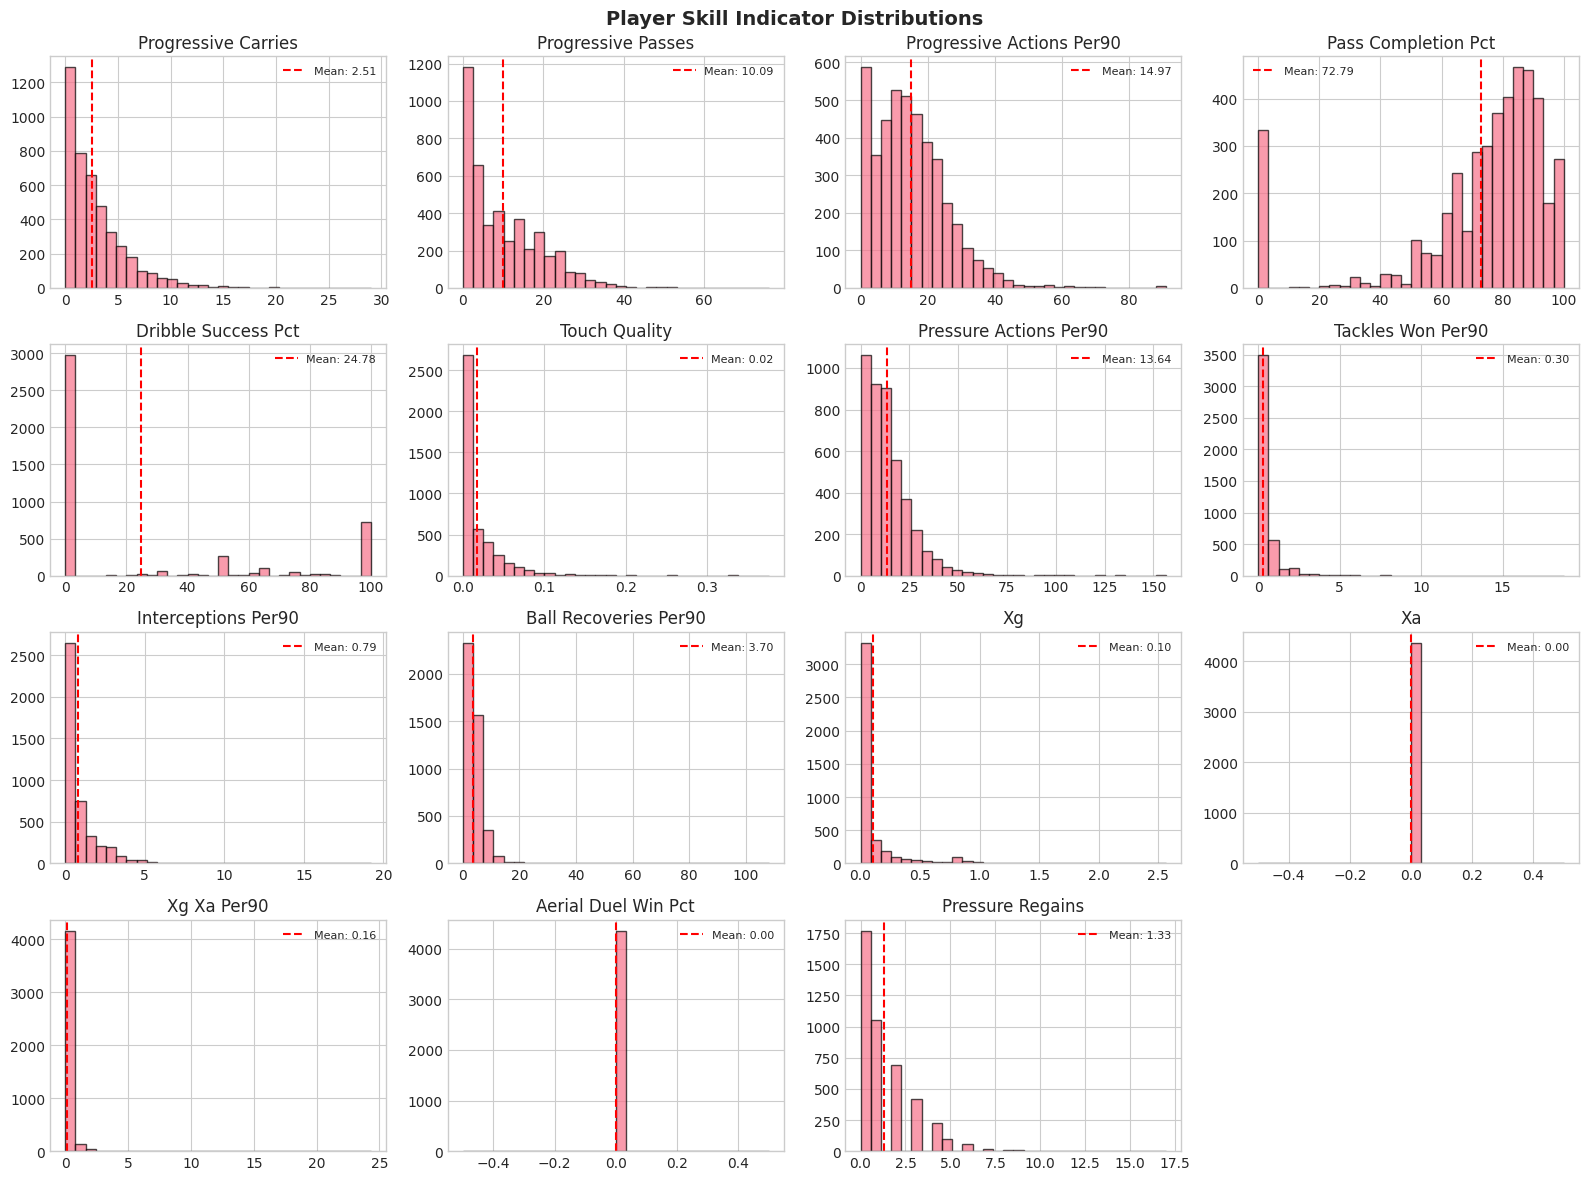

In [14]:
# Skill indicators distribution
skill_cols = [c for c in PLAYER_SKILL_INDICATORS if c in player_match_df.columns]
n_cols = 4
n_rows = (len(skill_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, indicator in enumerate(skill_cols):
    ax = axes[i]
    data = player_match_df[indicator].dropna()
    ax.hist(data, bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
    ax.set_title(indicator.replace('_', ' ').title())
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Player Skill Indicator Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Tactical Indicators Screening

For each tactical indicator, analyze:
- System-driven behavior
- Multi-collinearity with other tactical metrics
- Stability across matches
- Correlation with evolution

In [15]:
def screen_tactical_indicator(df, indicator, evolution_indicators):
    """Screen a tactical indicator."""
    if indicator not in df.columns:
        return None
    
    data = df[indicator].dropna()
    
    # Basic stats
    mean_val = data.mean()
    std_val = data.std()
    noise_ratio = std_val / mean_val if mean_val != 0 else np.inf
    missing_pct = df[indicator].isna().mean() * 100
    
    # Within-team stability (low std within team = more system-driven)
    team_stds = df.groupby('team_source_id')[indicator].std()
    avg_within_team_std = team_stds.mean()
    between_team_std = df.groupby('team_source_id')[indicator].mean().std()
    
    # System-driven ratio: high between-team variance, low within-team variance
    system_driven_ratio = between_team_std / avg_within_team_std if avg_within_team_std > 0 else np.inf
    
    # Correlation with evolution indicators
    correlations = {}
    for evo in evolution_indicators:
        if evo in df.columns:
            corr = df[[evo, indicator]].dropna().corr().iloc[0, 1]
            correlations[evo] = round(corr, 3) if not np.isnan(corr) else 0
    
    max_corr_evo = max(correlations.items(), key=lambda x: abs(x[1]))[0] if correlations else None
    max_corr_val = correlations.get(max_corr_evo, 0)
    
    return {
        'indicator': indicator,
        'mean': round(mean_val, 3),
        'std': round(std_val, 3),
        'noise_ratio': round(noise_ratio, 3),
        'missing_pct': round(missing_pct, 1),
        'system_driven_ratio': round(system_driven_ratio, 3),
        'max_evo_corr': max_corr_val,
        'max_evo_corr_with': max_corr_evo,
    }

# Screen all tactical indicators
tactical_screening = []
for ind in TACTICAL_INDICATORS:
    result = screen_tactical_indicator(team_match_df, ind, EVOLUTION_INDICATORS)
    if result:
        tactical_screening.append(result)

tactical_screening_df = pd.DataFrame(tactical_screening)
tactical_screening_df.sort_values('system_driven_ratio', ascending=False)

,indicator,mean,std,noise_ratio,missing_pct,system_driven_ratio,max_evo_corr,max_evo_corr_with
6,central_overload_rate,2.697,0.999,0.370,0.0,1.163,-0.616,build_up_pass_share
7,through_ball_rate,0.025,0.041,1.628,0.0,1.000,0.237,high_press_pct
9,passing_clustering_coeff,0.404,0.028,0.069,0.0,0.942,-0.228,build_up_pass_share
0,line_height_def,27.311,6.448,0.236,0.0,0.880,-0.760,vertical_compactness
2,cb_split_width,71.001,7.455,0.105,0.0,0.861,-0.106,high_press_pct
4,width_utilization_pct,33.586,4.740,0.141,0.0,0.849,0.287,build_up_pass_share
1,line_height_att,49.141,4.460,0.091,0.0,0.824,-0.660,transition_speed_sec
10,passing_asymmetry,-0.014,0.107,-7.756,0.0,0.763,-0.200,build_up_pass_share
3,pivot_involvement_pct,12.637,3.372,0.267,0.0,0.747,-0.376,build_up_pass_share
5,cross_rate,0.224,0.111,0.495,0.0,0.707,-0.466,build_up_pass_share


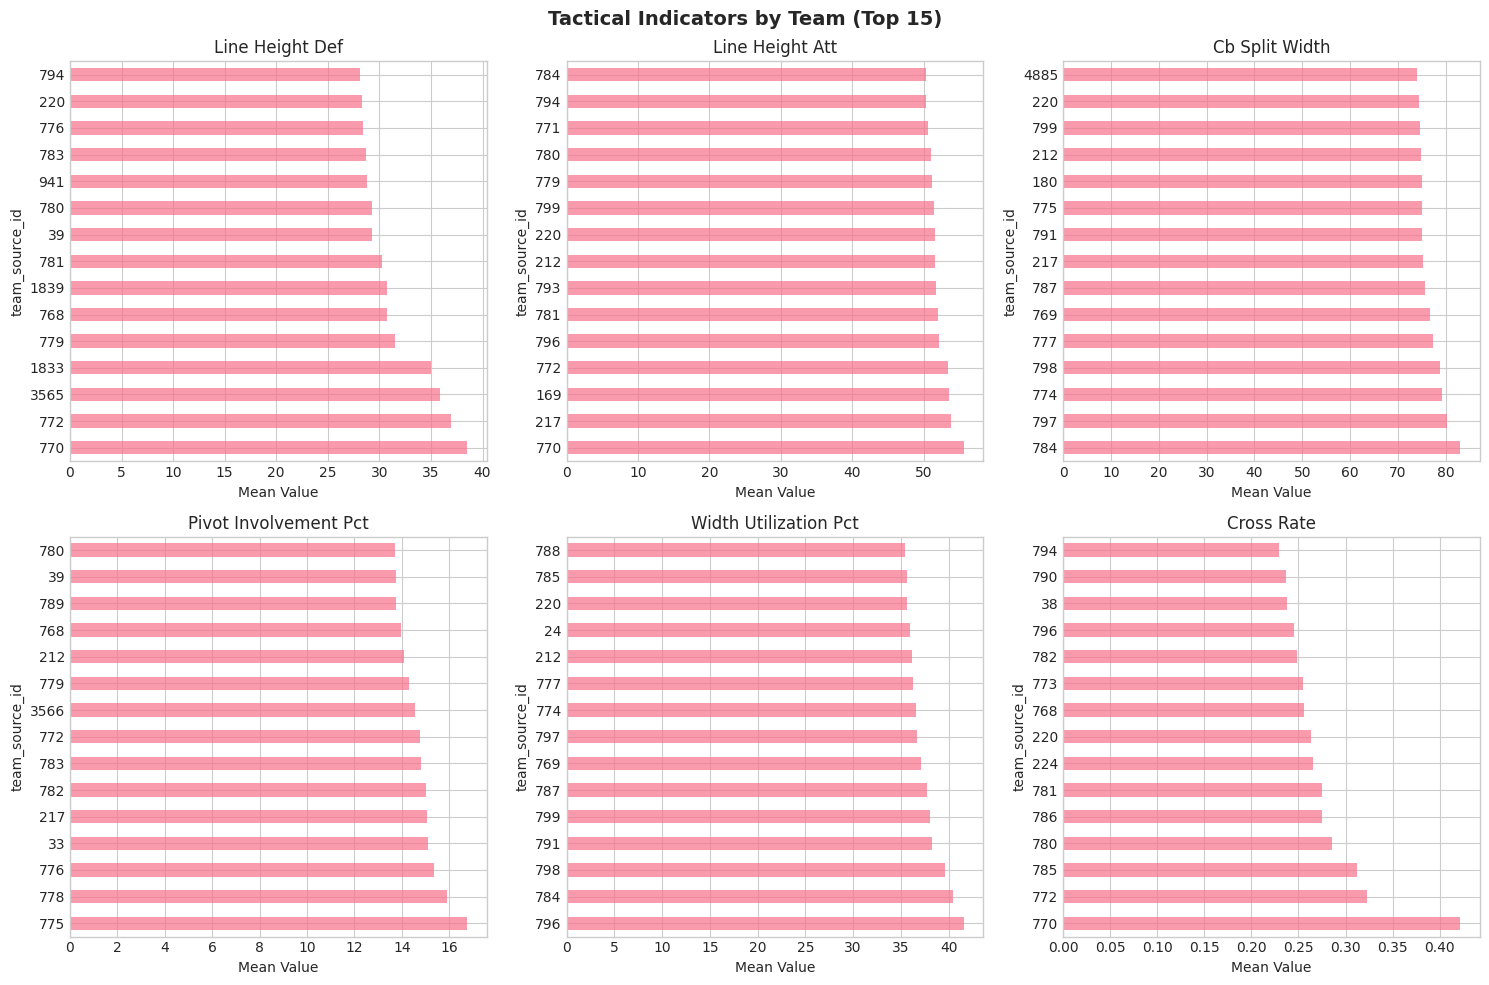

In [33]:
# Tactical indicators by team (shows system-driven nature)
tactical_cols = [c for c in TACTICAL_INDICATORS if c in team_match_df.columns][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, indicator in enumerate(tactical_cols):
    ax = axes[i]
    
    team_means = team_match_df.groupby('team_source_id')[indicator].mean().sort_values(ascending=False).head(15)
    team_means.plot(kind='barh', ax=ax, alpha=0.7)
    ax.set_title(indicator.replace('_', ' ').title())
    ax.set_xlabel('Mean Value')

plt.suptitle('Tactical Indicators by Team (Top 15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Correlation & Dependency Analysis

In [17]:
# Build unified team-match dataset with skill aggregates
skill_agg_cols = {}
for skill in PLAYER_SKILL_INDICATORS:
    if skill in player_match_df.columns:
        agg = player_match_df.groupby(['team_source_id', 'match_id'])[skill].mean().reset_index()
        agg.columns = ['team_source_id', 'match_id', f'squad_{skill}']
        skill_agg_cols[skill] = agg

# Merge all skill aggregates into team_match_df
unified_df = team_match_df.copy()
for skill, agg_df in skill_agg_cols.items():
    unified_df = unified_df.merge(agg_df, on=['team_source_id', 'match_id'], how='left')

print(f"Unified dataset: {unified_df.shape}")

Unified dataset: (278, 47)


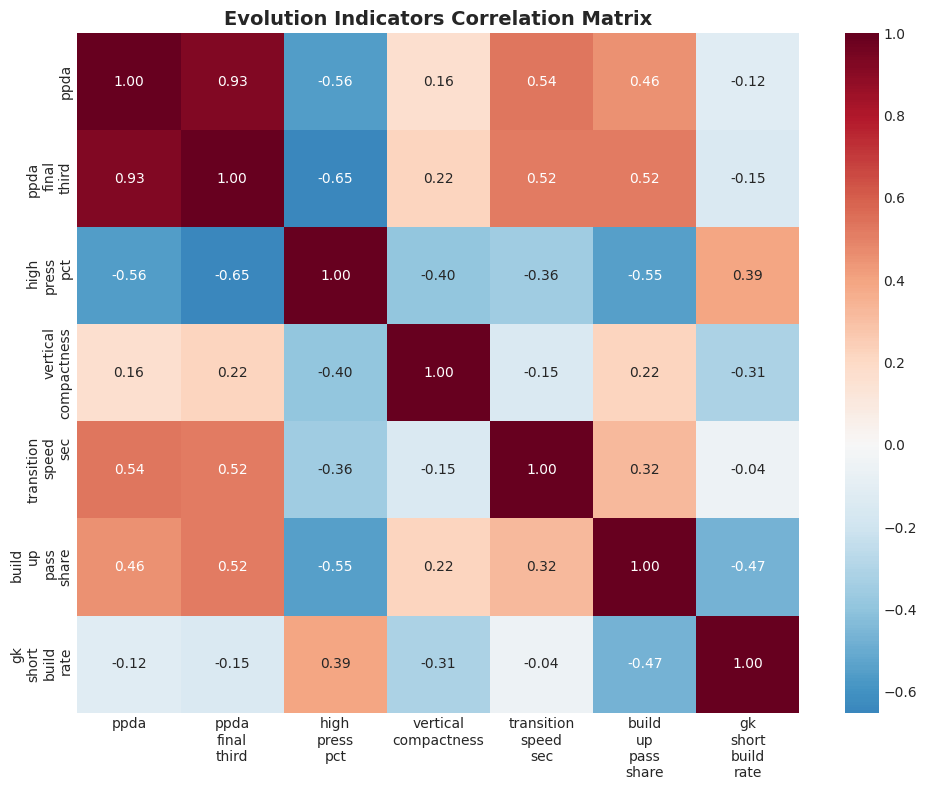

In [18]:
# Evolution indicators correlation matrix
evo_cols = [c for c in EVOLUTION_INDICATORS if c in unified_df.columns]
evo_corr = unified_df[evo_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(evo_corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            xticklabels=[c.replace('_', '\n') for c in evo_cols],
            yticklabels=[c.replace('_', '\n') for c in evo_cols])
plt.title('Evolution Indicators Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

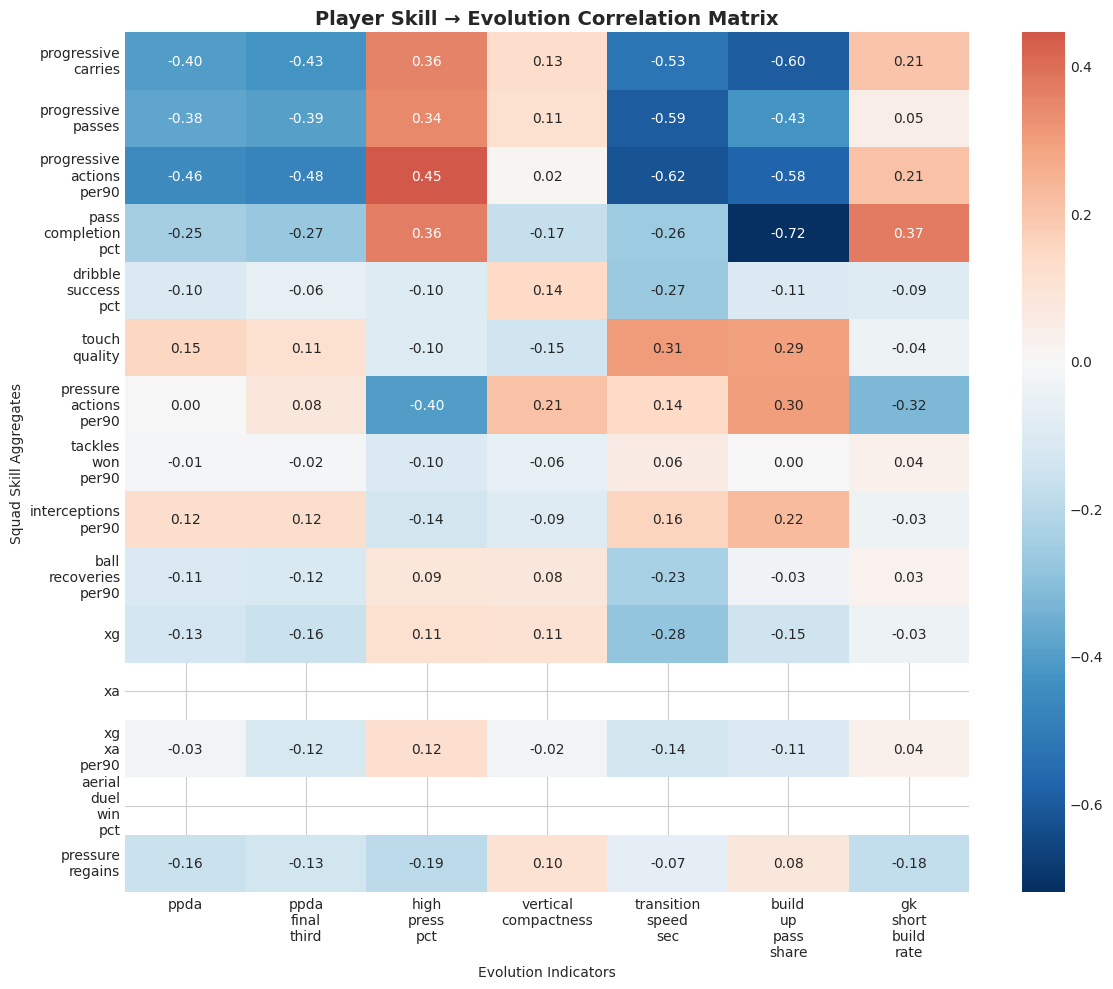

In [19]:
# Skill → Evolution correlation matrix
squad_skill_cols = [f'squad_{c}' for c in PLAYER_SKILL_INDICATORS if f'squad_{c}' in unified_df.columns]

skill_evo_corr = pd.DataFrame(index=squad_skill_cols, columns=evo_cols)
for skill in squad_skill_cols:
    for evo in evo_cols:
        corr = unified_df[[skill, evo]].dropna().corr().iloc[0, 1]
        skill_evo_corr.loc[skill, evo] = corr

skill_evo_corr = skill_evo_corr.astype(float)

plt.figure(figsize=(12, 10))
sns.heatmap(skill_evo_corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            xticklabels=[c.replace('_', '\n') for c in evo_cols],
            yticklabels=[c.replace('squad_', '').replace('_', '\n') for c in squad_skill_cols])
plt.title('Player Skill → Evolution Correlation Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Evolution Indicators')
plt.ylabel('Squad Skill Aggregates')
plt.tight_layout()
plt.show()

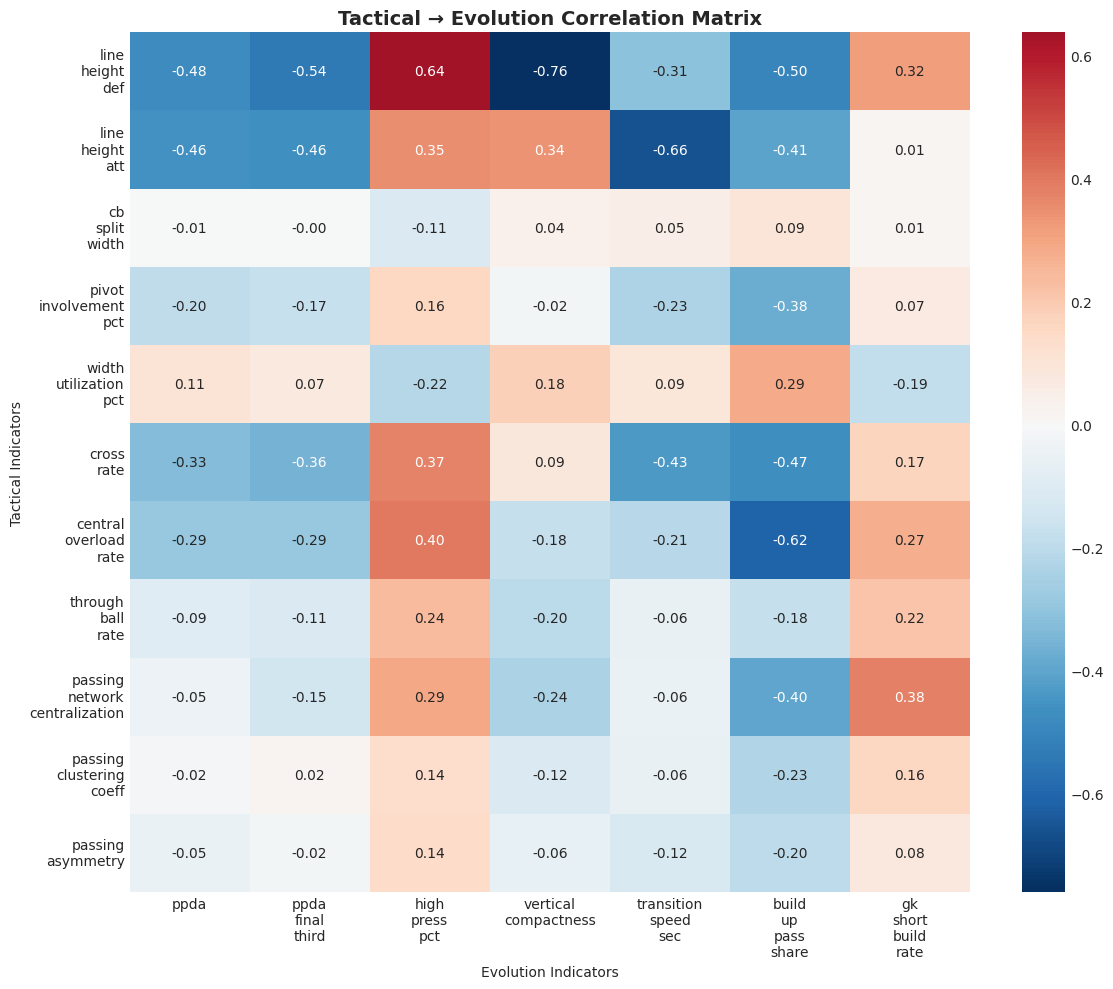

In [20]:
# Tactical → Evolution correlation matrix
tact_cols = [c for c in TACTICAL_INDICATORS if c in unified_df.columns]

tact_evo_corr = pd.DataFrame(index=tact_cols, columns=evo_cols)
for tact in tact_cols:
    for evo in evo_cols:
        corr = unified_df[[tact, evo]].dropna().corr().iloc[0, 1]
        tact_evo_corr.loc[tact, evo] = corr

tact_evo_corr = tact_evo_corr.astype(float)

plt.figure(figsize=(12, 10))
sns.heatmap(tact_evo_corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            xticklabels=[c.replace('_', '\n') for c in evo_cols],
            yticklabels=[c.replace('_', '\n') for c in tact_cols])
plt.title('Tactical → Evolution Correlation Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Evolution Indicators')
plt.ylabel('Tactical Indicators')
plt.tight_layout()
plt.show()

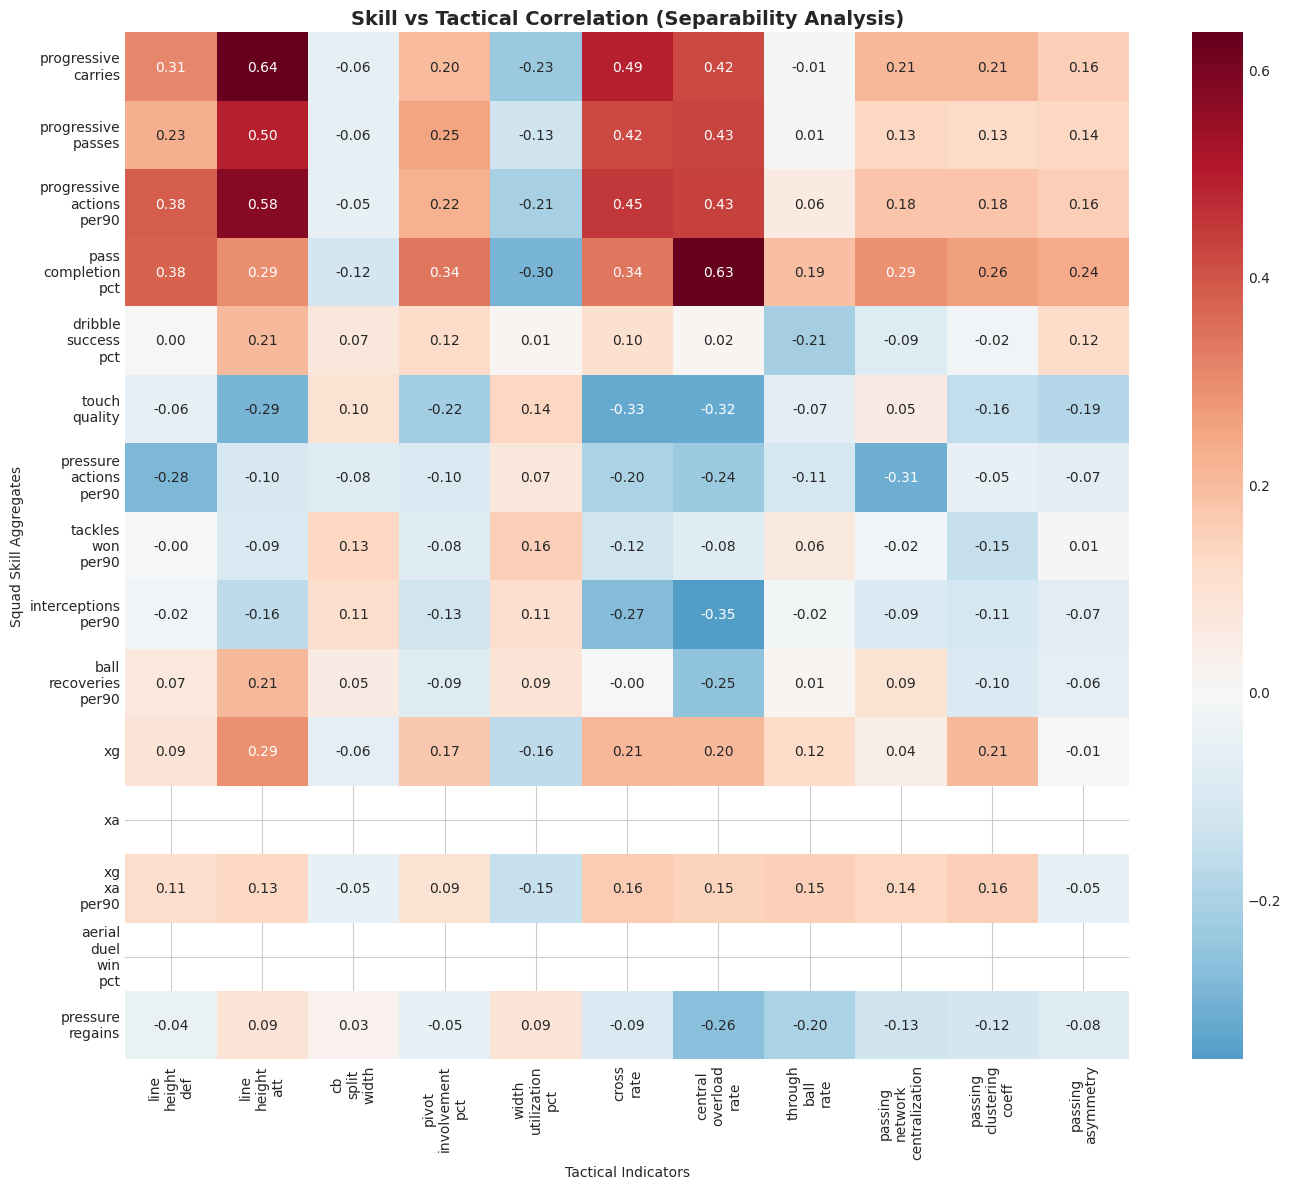


⚠️ Highly Correlated Skill-Tactical Pairs (|r| > 0.5):
  progressive_carries ↔ line_height_att: r = 0.636
  progressive_actions_per90 ↔ line_height_att: r = 0.576
  pass_completion_pct ↔ central_overload_rate: r = 0.632


In [21]:
# Skill vs Tactical correlation matrix (separability analysis)
skill_tact_corr = pd.DataFrame(index=squad_skill_cols, columns=tact_cols)
for skill in squad_skill_cols:
    for tact in tact_cols:
        corr = unified_df[[skill, tact]].dropna().corr().iloc[0, 1]
        skill_tact_corr.loc[skill, tact] = corr

skill_tact_corr = skill_tact_corr.astype(float)

plt.figure(figsize=(14, 12))
sns.heatmap(skill_tact_corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            xticklabels=[c.replace('_', '\n') for c in tact_cols],
            yticklabels=[c.replace('squad_', '').replace('_', '\n') for c in squad_skill_cols])
plt.title('Skill vs Tactical Correlation (Separability Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Tactical Indicators')
plt.ylabel('Squad Skill Aggregates')
plt.tight_layout()
plt.show()

# Find highly correlated pairs (potential confounding)
print("\n⚠️ Highly Correlated Skill-Tactical Pairs (|r| > 0.5):")
for skill in squad_skill_cols:
    for tact in tact_cols:
        corr = skill_tact_corr.loc[skill, tact]
        if abs(corr) > 0.5:
            print(f"  {skill.replace('squad_', '')} ↔ {tact}: r = {corr:.3f}")

---
## 7. Era/Season Analysis

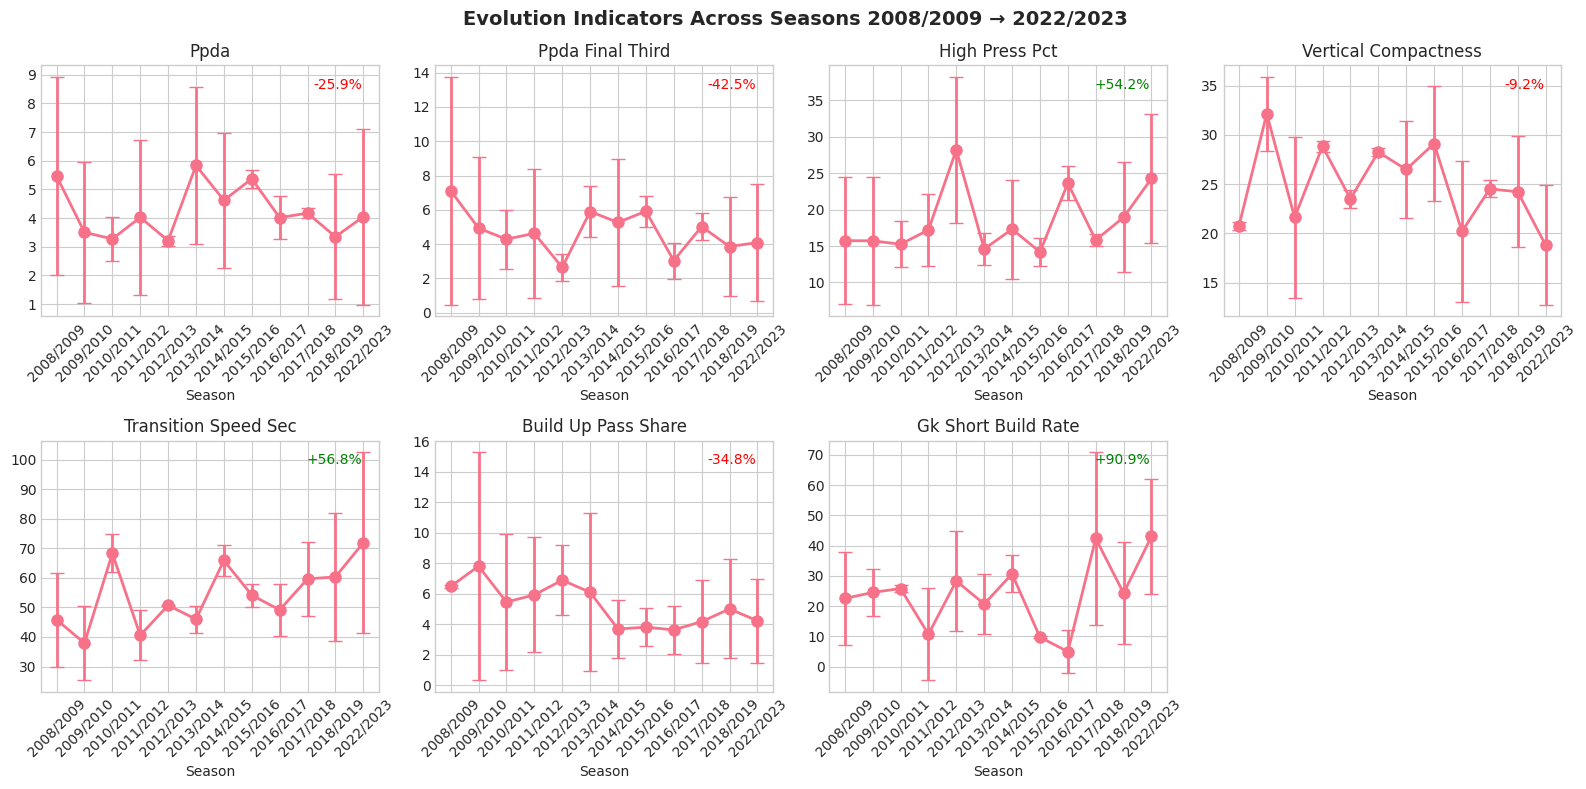

In [22]:
# Evolution indicators time-series by season
season_evolution = team_match_df.groupby('season_name')[evo_cols].agg(['mean', 'std']).reset_index()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, indicator in enumerate(evo_cols):
    if i >= len(axes):
        break
    ax = axes[i]
    
    means = season_evolution[(indicator, 'mean')]
    stds = season_evolution[(indicator, 'std')]
    seasons = season_evolution['season_name'].astype(str)
    
    ax.errorbar(seasons, means, yerr=stds, marker='o', capsize=5, linewidth=2, markersize=8)
    ax.set_title(indicator.replace('_', ' ').title())
    ax.set_xlabel('Season')
    ax.set_xticklabels(seasons, rotation=45)
    
    # Add trend annotation
    if len(means) > 1:
        change = ((means.iloc[-1] - means.iloc[0]) / means.iloc[0]) * 100 if means.iloc[0] != 0 else 0
        ax.annotate(f'{change:+.1f}%', xy=(0.95, 0.95), xycoords='axes fraction', 
                   ha='right', va='top', fontsize=10, color='green' if change > 0 else 'red')

if len(evo_cols) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle(f'Evolution Indicators Across Seasons {seasons.iloc[0]} → {seasons.iloc[-1]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# Era comparison summary table - compare all consecutive season pairs
era_comparison = []

# Get sorted list of seasons
sorted_seasons = sort_seasons(team_match_df['season_name'].unique())

for indicator in evo_cols:
    season_stats = team_match_df.groupby('season_name')[indicator].agg(['mean', 'std'])
    
    # Compare each season with the next
    for i in range(len(sorted_seasons) - 1):
        s1, s2 = sorted_seasons[i], sorted_seasons[i + 1]
        
        if s1 in season_stats.index and s2 in season_stats.index:
            mean_s1 = season_stats.loc[s1, 'mean']
            mean_s2 = season_stats.loc[s2, 'mean']
            pct_change = ((mean_s2 - mean_s1) / mean_s1) * 100 if mean_s1 != 0 else 0
            
            # Statistical test (t-test between consecutive seasons)
            data_s1 = team_match_df[team_match_df['season_name'] == s1][indicator].dropna()
            data_s2 = team_match_df[team_match_df['season_name'] == s2][indicator].dropna()
            
            if len(data_s1) > 1 and len(data_s2) > 1:
                t_stat, p_value = stats.ttest_ind(data_s1, data_s2)
            else:
                t_stat, p_value = 0, 1
            
            era_comparison.append({
                'indicator': indicator,
                'from_season': s1,
                'to_season': s2,
                'mean_from': round(mean_s1, 3),
                'mean_to': round(mean_s2, 3),
                'pct_change': round(pct_change, 1),
                'p_value': round(p_value, 4),
                'significant': '✓' if p_value < 0.05 else ''
            })

era_comparison_df = pd.DataFrame(era_comparison)

# Display the full comparison
print(f"All Era-to-Era Comparisons ({len(sorted_seasons)-1} transitions):")
print("=" * 80)
era_comparison_df.sort_values(['from_season', 'pct_change'], key=lambda x: abs(x) if x.name == 'pct_change' else x, ascending=[True, False])

All Era-to-Era Comparisons (11 transitions):


,indicator,from_season,to_season,mean_from,mean_to,pct_change,p_value,significant
33,vertical_compactness,2008/2009,2009/2010,20.726,32.155,55.1,0.0505,
0,ppda,2008/2009,2009/2010,5.466,3.505,-35.9,0.5806,
11,ppda_final_third,2008/2009,2009/2010,7.117,4.932,-30.7,0.7313,
55,build_up_pass_share,2008/2009,2009/2010,6.478,7.803,20.5,0.8253,
44,transition_speed_sec,2008/2009,2009/2010,45.864,37.873,-17.4,0.6330,
...,...,...,...,...,...,...,...,...
43,vertical_compactness,2018/2019,2022/2023,24.227,18.816,-22.3,0.0000,✓
10,ppda,2018/2019,2022/2023,3.350,4.048,20.9,0.0360,✓
54,transition_speed_sec,2018/2019,2022/2023,60.316,71.896,19.2,0.0005,✓
65,build_up_pass_share,2018/2019,2022/2023,5.003,4.224,-15.6,0.0393,✓


In [37]:
# Summary: Biggest changes across all eras by indicator
print("\nBiggest Changes by Indicator (All Eras):")
print("=" * 80)

for indicator in evo_cols:
    ind_changes = era_comparison_df[era_comparison_df['indicator'] == indicator]
    max_change = ind_changes.loc[ind_changes['pct_change'].abs().idxmax()]
    
    print(f"\n{indicator}:")
    print(f"  Largest change: {max_change['from_season']} → {max_change['to_season']}: {max_change['pct_change']:+.1f}%")
    print(f"  Significant: {max_change['significant']}")
    
    # Show all transitions for this indicator
    print(f"  All transitions:")
    for _, row in ind_changes.iterrows():
        sig_marker = "***" if row['significant'] else "   "
        print(f"    {sig_marker} {row['from_season']} → {row['to_season']}: {row['pct_change']:+.1f}% (p={row['p_value']:.4f})")

# Overall summary: which era transition had most indicators changing?
print("\n" + "=" * 80)
print("Era Transitions with Most Significant Changes:")
print("=" * 80)

transition_summary = era_comparison_df.groupby(['from_season', 'to_season']).agg({
    'significant': lambda x: (x == '✓').sum(),
    'pct_change': lambda x: x.abs().mean()
}).reset_index()
transition_summary.columns = ['from_season', 'to_season', 'num_significant', 'avg_abs_change']
transition_summary = transition_summary.sort_values('num_significant', ascending=False)

for _, row in transition_summary.iterrows():
    print(f"{row['from_season']} → {row['to_season']}: {row['num_significant']} significant changes, avg |Δ|={row['avg_abs_change']:.1f}%")


Biggest Changes by Indicator (All Eras):

ppda:
  Largest change: 2012/2013 → 2013/2014: +81.6%
  Significant: 
  All transitions:
        2008/2009 → 2009/2010: -35.9% (p=0.5806)
        2009/2010 → 2010/2011: -6.6% (p=0.9106)
        2010/2011 → 2011/2012: +23.0% (p=0.7407)
        2011/2012 → 2012/2013: -20.2% (p=0.7121)
        2012/2013 → 2013/2014: +81.6% (p=0.3082)
        2013/2014 → 2014/2015: -20.8% (p=0.6812)
        2014/2015 → 2015/2016: +16.2% (p=0.7002)
        2015/2016 → 2016/2017: -25.2% (p=0.1446)
        2016/2017 → 2017/2018: +4.0% (p=0.7987)
        2017/2018 → 2018/2019: -19.8% (p=0.5960)
    *** 2018/2019 → 2022/2023: +20.9% (p=0.0360)

ppda_final_third:
  Largest change: 2012/2013 → 2013/2014: +123.3%
  Significant: 
  All transitions:
        2008/2009 → 2009/2010: -30.7% (p=0.7313)
        2009/2010 → 2010/2011: -13.1% (p=0.8578)
        2010/2011 → 2011/2012: +8.0% (p=0.9168)
        2011/2012 → 2012/2013: -42.9% (p=0.5398)
        2012/2013 → 2013/2014: +1

---
## 8. PCA & Clustering Analysis

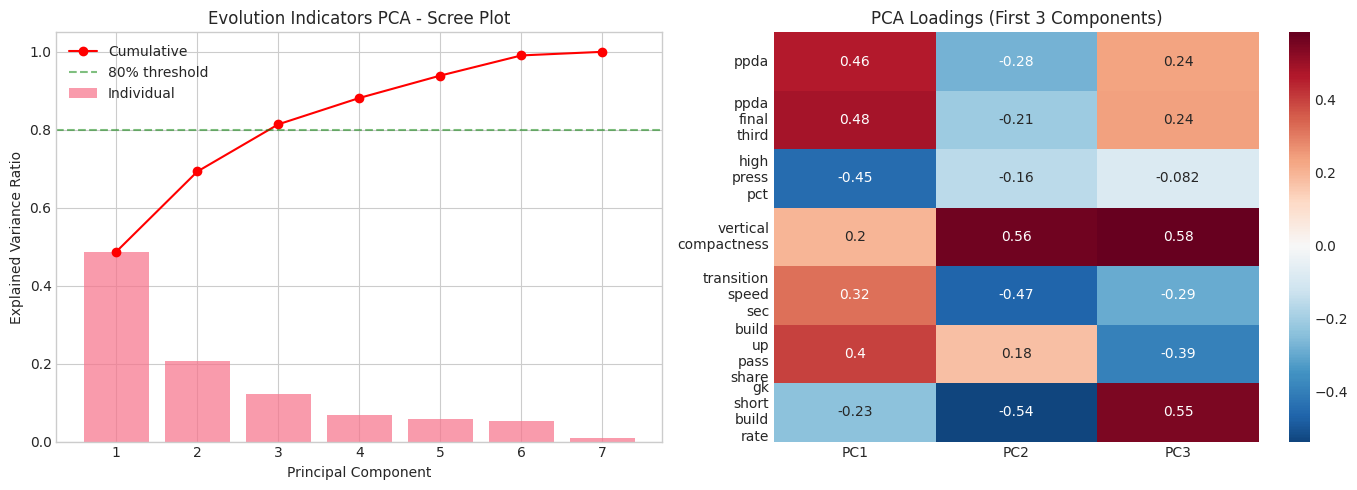


Evolution Indicator Clusters (from PC loadings):
  PC1: +[ppda_final_third, ppda] vs -[high_press_pct, gk_short_build_rate]
  PC2: +[vertical_compactness, build_up_pass_share] vs -[gk_short_build_rate, transition_speed_sec]
  PC3: +[vertical_compactness, gk_short_build_rate] vs -[build_up_pass_share, transition_speed_sec]


In [24]:
# PCA on evolution indicators
evo_data = unified_df[evo_cols].dropna()

scaler = StandardScaler()
evo_scaled = scaler.fit_transform(evo_data)

pca = PCA()
evo_pca = pca.fit_transform(evo_scaled)

# Explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
            pca.explained_variance_ratio_, alpha=0.7, label='Individual')
axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1), 
             np.cumsum(pca.explained_variance_ratio_), 'ro-', label='Cumulative')
axes[0].axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='80% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Evolution Indicators PCA - Scree Plot')
axes[0].legend()

# Loadings
loadings = pd.DataFrame(
    pca.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=evo_cols
)
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, ax=axes[1],
            yticklabels=[c.replace('_', '\n') for c in evo_cols])
axes[1].set_title('PCA Loadings (First 3 Components)')

plt.tight_layout()
plt.show()

print("\nEvolution Indicator Clusters (from PC loadings):")
for pc in ['PC1', 'PC2', 'PC3']:
    top_positive = loadings[pc].nlargest(2).index.tolist()
    top_negative = loadings[pc].nsmallest(2).index.tolist()
    print(f"  {pc}: +[{', '.join(top_positive)}] vs -[{', '.join(top_negative)}]")

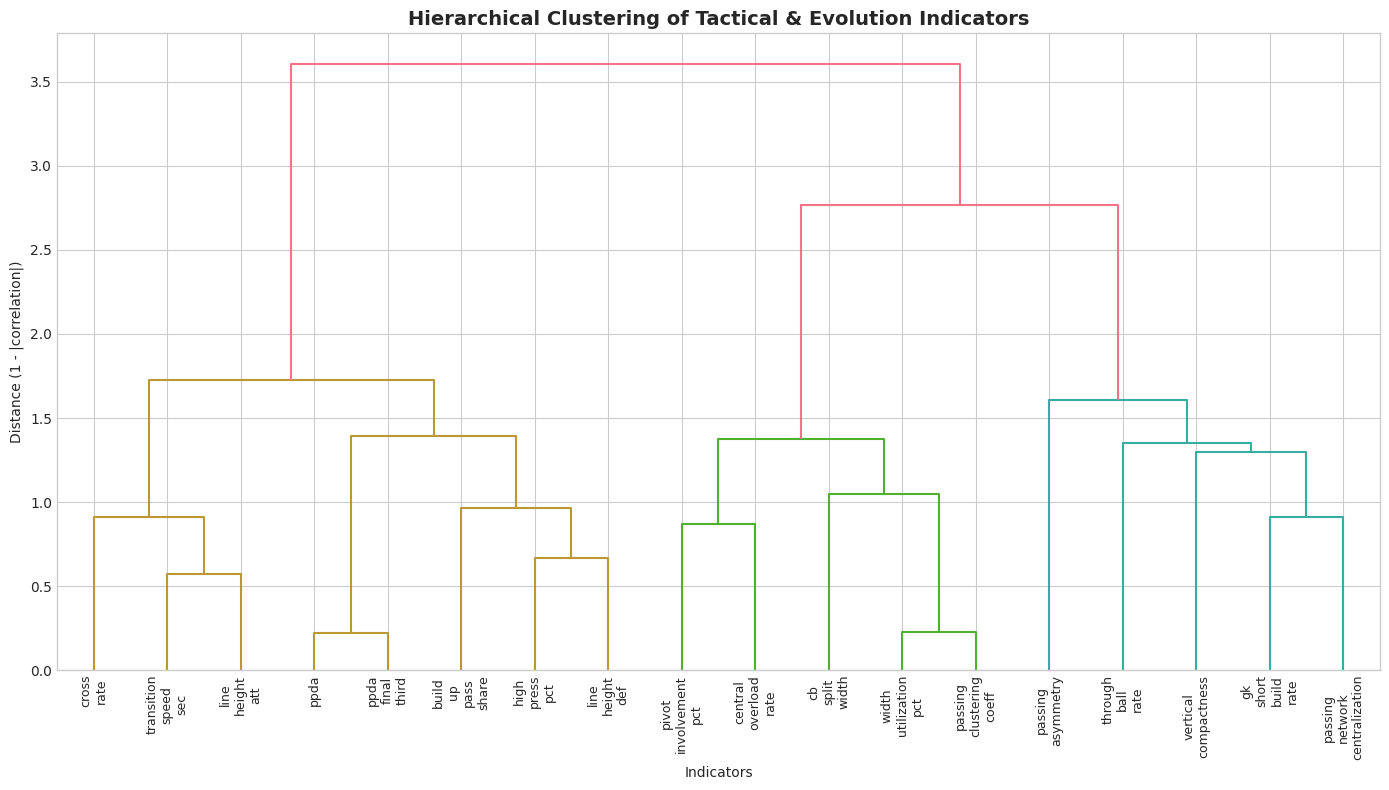

In [25]:
# Hierarchical clustering of all indicators
all_indicator_cols = evo_cols + tact_cols
all_data = unified_df[all_indicator_cols].dropna()

# Correlation-based distance
corr_matrix = all_data.corr()
distance_matrix = 1 - np.abs(corr_matrix)

# Hierarchical clustering
linkage_matrix = linkage(distance_matrix, method='ward')

plt.figure(figsize=(14, 8))
dendrogram(linkage_matrix, labels=[c.replace('_', '\n') for c in all_indicator_cols],
           leaf_rotation=90, leaf_font_size=9)
plt.title('Hierarchical Clustering of Tactical & Evolution Indicators', fontsize=14, fontweight='bold')
plt.xlabel('Indicators')
plt.ylabel('Distance (1 - |correlation|)')
plt.tight_layout()
plt.show()

In [26]:
# Assign cluster labels
n_clusters = 4
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({
    'indicator': all_indicator_cols,
    'cluster': cluster_labels,
    'type': ['evolution' if c in evo_cols else 'tactical' for c in all_indicator_cols]
})

print("\nIndicator Clusters:")
for cluster_id in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    for _, row in members.iterrows():
        print(f"  [{row['type'][:4]}] {row['indicator']}")


Indicator Clusters:

Cluster 1:
  [evol] transition_speed_sec
  [tact] line_height_att
  [tact] cross_rate

Cluster 2:
  [evol] ppda
  [evol] ppda_final_third
  [evol] high_press_pct
  [evol] build_up_pass_share
  [tact] line_height_def

Cluster 3:
  [tact] cb_split_width
  [tact] pivot_involvement_pct
  [tact] width_utilization_pct
  [tact] central_overload_rate
  [tact] passing_clustering_coeff

Cluster 4:
  [evol] vertical_compactness
  [evol] gk_short_build_rate
  [tact] through_ball_rate
  [tact] passing_network_centralization
  [tact] passing_asymmetry


---
## 9. Final Indicator Selection

In [27]:
# Score indicators based on screening criteria

def score_indicator(row, is_evolution=False):
    """Score an indicator for inclusion in final model."""
    score = 0
    
    # Low noise is good
    if row.get('noise_ratio', 1) < 1:
        score += 2
    elif row.get('noise_ratio', 1) < 2:
        score += 1
    
    # Low missing is good
    if row.get('missing_pct', 0) < 5:
        score += 2
    elif row.get('missing_pct', 0) < 10:
        score += 1
    
    # For evolution: trend strength matters
    if is_evolution:
        if row.get('trend_r2', 0) > 0.5:
            score += 2
        if row.get('inter_season_cv', 0) > 0.1:
            score += 1
    
    # For skill/tactical: correlation with evolution matters
    if not is_evolution:
        corr = abs(row.get('max_evo_corr', 0))
        if corr > 0.3:
            score += 2
        elif corr > 0.15:
            score += 1
    
    # For tactical: system-driven ratio matters
    if 'system_driven_ratio' in row:
        if row['system_driven_ratio'] > 1.5:
            score += 2
        elif row['system_driven_ratio'] > 1:
            score += 1
    
    return score

# Score evolution indicators
evolution_screening_df['score'] = evolution_screening_df.apply(
    lambda r: score_indicator(r, is_evolution=True), axis=1
)
evolution_screening_df['candidate'] = evolution_screening_df['score'] >= 3

# Score skill indicators
skill_screening_df['score'] = skill_screening_df.apply(
    lambda r: score_indicator(r, is_evolution=False), axis=1
)
skill_screening_df['candidate'] = skill_screening_df['score'] >= 3

# Score tactical indicators
tactical_screening_df['score'] = tactical_screening_df.apply(
    lambda r: score_indicator(r, is_evolution=False), axis=1
)
tactical_screening_df['candidate'] = tactical_screening_df['score'] >= 3

In [28]:
print("=" * 80)
print("FINAL INDICATOR SELECTION")
print("=" * 80)

print("\n📊 EVOLUTION INDICATORS (Targets)")
print("-" * 60)
evo_ranked = evolution_screening_df.sort_values('score', ascending=False)
for i, row in evo_ranked.iterrows():
    status = "✓ SELECTED" if row['candidate'] else "✗ excluded"
    print(f"  {status}: {row['indicator']} (score={row['score']}, noise={row['noise_ratio']:.2f})")

print("\n🧑 PLAYER SKILL INDICATORS (Predictor Block A)")
print("-" * 60)
skill_ranked = skill_screening_df.sort_values('score', ascending=False)
for i, row in skill_ranked.iterrows():
    status = "✓ SELECTED" if row['candidate'] else "✗ excluded"
    corr_info = f"r={row['max_evo_corr']:.2f} with {row['max_evo_corr_with']}" if row['max_evo_corr_with'] else ""
    print(f"  {status}: {row['indicator']} (score={row['score']}, {corr_info})")

print("\n⚽ TACTICAL INDICATORS (Predictor Block B)")
print("-" * 60)
tact_ranked = tactical_screening_df.sort_values('score', ascending=False)
for i, row in tact_ranked.iterrows():
    status = "✓ SELECTED" if row['candidate'] else "✗ excluded"
    sys_info = f"system_ratio={row['system_driven_ratio']:.2f}" if 'system_driven_ratio' in row else ""
    print(f"  {status}: {row['indicator']} (score={row['score']}, {sys_info})")

FINAL INDICATOR SELECTION

📊 EVOLUTION INDICATORS (Targets)
------------------------------------------------------------
  ✓ SELECTED: build_up_pass_share (score=7, noise=0.65)
  ✓ SELECTED: ppda_final_third (score=5, noise=0.78)
  ✓ SELECTED: ppda (score=5, noise=0.70)
  ✓ SELECTED: high_press_pct (score=5, noise=0.40)
  ✓ SELECTED: vertical_compactness (score=5, noise=0.29)
  ✓ SELECTED: transition_speed_sec (score=5, noise=0.41)
  ✓ SELECTED: gk_short_build_rate (score=5, noise=0.61)

🧑 PLAYER SKILL INDICATORS (Predictor Block A)
------------------------------------------------------------
  ✓ SELECTED: progressive_passes (score=6, r=-0.59 with transition_speed_sec)
  ✓ SELECTED: progressive_actions_per90 (score=6, r=-0.62 with transition_speed_sec)
  ✓ SELECTED: pass_completion_pct (score=6, r=-0.72 with build_up_pass_share)
  ✓ SELECTED: pressure_actions_per90 (score=6, r=-0.40 with high_press_pct)
  ✓ SELECTED: progressive_carries (score=5, r=-0.60 with build_up_pass_share)
  ✓ S

In [29]:
# Final selected indicators
SELECTED_EVOLUTION = evolution_screening_df[evolution_screening_df['candidate']]['indicator'].tolist()
SELECTED_SKILL = skill_screening_df[skill_screening_df['candidate']]['indicator'].tolist()
SELECTED_TACTICAL = tactical_screening_df[tactical_screening_df['candidate']]['indicator'].tolist()

print("\n" + "=" * 80)
print("PHASE 3.5 SUMMARY - INDICATORS FOR PHASE 4 MODELLING")
print("=" * 80)

print(f"\n📊 Evolution Indicators ({len(SELECTED_EVOLUTION)} selected):")
for ind in SELECTED_EVOLUTION:
    print(f"   • {ind}")

print(f"\n🧑 Player Skill Indicators ({len(SELECTED_SKILL)} selected):")
for ind in SELECTED_SKILL:
    print(f"   • {ind}")

print(f"\n⚽ Tactical Indicators ({len(SELECTED_TACTICAL)} selected):")
for ind in SELECTED_TACTICAL:
    print(f"   • {ind}")


PHASE 3.5 SUMMARY - INDICATORS FOR PHASE 4 MODELLING

📊 Evolution Indicators (7 selected):
   • ppda
   • ppda_final_third
   • high_press_pct
   • vertical_compactness
   • transition_speed_sec
   • build_up_pass_share
   • gk_short_build_rate

🧑 Player Skill Indicators (11 selected):
   • progressive_carries
   • progressive_passes
   • progressive_actions_per90
   • pass_completion_pct
   • dribble_success_pct
   • touch_quality
   • pressure_actions_per90
   • interceptions_per90
   • ball_recoveries_per90
   • xg
   • pressure_regains

⚽ Tactical Indicators (11 selected):
   • line_height_def
   • line_height_att
   • cb_split_width
   • pivot_involvement_pct
   • width_utilization_pct
   • cross_rate
   • central_overload_rate
   • through_ball_rate
   • passing_network_centralization
   • passing_clustering_coeff
   • passing_asymmetry


In [30]:
# Save selected indicators for Phase 4
selected_indicators = {
    'evolution': SELECTED_EVOLUTION,
    'player_skill': SELECTED_SKILL,
    'tactical': SELECTED_TACTICAL,
    'screening_summary': {
        'evolution': evolution_screening_df.to_dict(orient='records'),
        'skill': skill_screening_df.to_dict(orient='records'),
        'tactical': tactical_screening_df.to_dict(orient='records'),
    }
}

import json
output_path = Path('../data/features/selected_indicators.json')
with open(output_path, 'w') as f:
    json.dump(selected_indicators, f, indent=2)

print(f"\n✅ Saved selected indicators to {output_path}")


✅ Saved selected indicators to ../data/features/selected_indicators.json


---
## 10. Narrative Summary

### Key Findings

**Evolution Indicators:**
- PPDA and high_press_pct show clear tactical evolution between World Cup 2018 and 2022
- Build-up metrics (gk_short_build_rate, build_up_pass_share) indicate positional play adoption
- Vertical compactness captures team shape evolution

**Player Skill Indicators:**
- Progressive actions (carries, passes) strongly correlate with evolution metrics
- Technical metrics (pass_completion, dribble_success) show player-driven quality
- Defensive metrics (tackles, interceptions) less correlated - may be system-influenced

**Tactical Indicators:**
- Line heights (def, att) show strong system-driven behavior (high between-team variance)
- Network centralization indicates star-dependency patterns
- Width and crossing metrics differentiate tactical styles

**Separability Analysis:**
- Some skill-tactical correlations exist (e.g., progressive passes ↔ build_up_pass_share)
- This suggests partial confounding that Phase 4 models must address
- Pure player skills (dribble_success, aerial duels) show lower tactical correlation

### Recommendations for Phase 4

1. Use selected evolution indicators as **target variables** for variance decomposition
2. Build separate **M_skill** and **M_tactic** models with selected indicators
3. Account for skill-tactical correlation in **M_combined** interpretation
4. Consider removing highly correlated indicators to reduce multicollinearity